<a href="https://colab.research.google.com/github/julierosina/advancedpythonmovies/blob/main/Data_preprocessing%2C_EDA%2C_and_model_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data preprocessing

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
import kagglehub
import os

path = kagglehub.dataset_download("tmdb/tmdb-movie-metadata")
print("Path:", path)
print("Files:", os.listdir(path))

Using Colab cache for faster access to the 'tmdb-movie-metadata' dataset.
Path: /kaggle/input/tmdb-movie-metadata
Files: ['tmdb_5000_movies.csv', 'tmdb_5000_credits.csv']


In [10]:
import os
print(os.listdir(path))

['tmdb_5000_movies.csv', 'tmdb_5000_credits.csv']


In [11]:
print(path)

/kaggle/input/tmdb-movie-metadata


In [12]:
import os
import pandas as pd
import numpy as np
import ast

movies  = pd.read_csv("https://docs.google.com/spreadsheets/d/1tFXWzYpODrwV4vaHdbegk7taMzaaKSUH5kvXvW-qYX4/export?format=csv&gid=2022484258")
credits = pd.read_csv("https://docs.google.com/spreadsheets/d/1ApKIOuyv5qGY0u-lo0Ofi1l8BnXMRAlP-jFzAAT7WEk/export?format=csv&gid=1914985060")

# HELPER FUNCTIONS

def extract_genre_names(genre_str):
    try:
        return [g["name"] for g in ast.literal_eval(genre_str)]
    except (ValueError, TypeError):
        return []
#extract genre names is useful as it allows us to return only the names, which is not the case in the data set


def make_binary_outcome(series):
    q25, q75 = series.quantile([0.25, 0.75])
    print(f"  → thresholds: bottom ≤ {q25:.2f}, top ≥ {q75:.2f}")
    return np.where(series >= q75, 1, np.where(series <= q25, 0, np.nan))
#make binary outcomes is used to code the top quartile as 1 (high quality), the bottom quartile as 0 (low quality)and the medidum (so between 5.70 and 6.8O)as NaN, basically thrown out


def save_model_dataset(df, outcome_col, raw_col, feature_cols, filename):
    out = df.dropna(subset=[outcome_col]).copy()
    out[outcome_col] = out[outcome_col].astype(int)
    out[["id", "title"] + feature_cols + [raw_col, outcome_col]].to_csv(filename, index=False)
    print(f"  {filename}: {out.shape[0]} rows saved")


# =============================================================================
# 1. LOAD AND MERGE
# =============================================================================

# Load the two CSV files uploaded to Colab
movies  = pd.read_csv(os.path.join(path, "tmdb_5000_movies.csv"))
credits = pd.read_csv(os.path.join(path, "tmdb_5000_credits.csv"))

# Align merge key and resolve duplicate title column produced by the merge
credits.rename(columns={"movie_id": "id"}, inplace=True)
df = movies.merge(credits, on="id").drop(columns=["title_y"]).rename(columns={"title_x": "title"})

print(f"Loaded: {df.shape[0]} rows, {df.shape[1]} columns")


# =============================================================================
# 2. SELECT RELEVANT COLUMNS
# =============================================================================

df = df[[
    "id", "title",
    "budget", "genres", "runtime", "release_date", "original_language",
    "vote_average", "vote_count", "popularity"
]].copy()


# =============================================================================
# 3. HANDLE MISSING VALUES
# =============================================================================

print("\nMissing values before cleaning:")
print(df.isnull().sum())

# Target variables cannot be imputed — drop any rows missing them
df.dropna(subset=["vote_average", "popularity", "release_date"], inplace=True)

# 0 means "not reported" for budget and runtime, so treat as missing
for col in ["budget", "runtime"]:
    df[col] = df[col].replace(0, np.nan)

# Drop rows missing both budget and runtime (too little information to be useful)
df.dropna(subset=["budget", "runtime"], how="all", inplace=True)

# Impute remaining missing values with the median (robust to skew)
for col in ["budget", "runtime"]:
    df[col] = df[col].fillna(df[col].median())

print(f"\nRows after handling missing values: {df.shape[0]}")


# =============================================================================
# 4. ENCODE GENRES AS BINARY INDICATOR COLUMNS
# =============================================================================

# Genres are stored as a JSON-like string; parse them into lists first
df["genres_list"] = df["genres"].apply(extract_genre_names)

# Create one binary column per genre (1 = movie belongs to that genre)
top_genres = [
    "Action", "Adventure", "Animation", "Comedy", "Crime",
    "Documentary", "Drama", "Family", "Fantasy", "Horror",
    "Mystery", "Romance", "Science Fiction", "Thriller"
]
for genre in top_genres:
    df[f"genre_{genre.lower().replace(' ', '_')}"] = (
        df["genres_list"].apply(lambda g: int(genre in g))
    )

df.drop(columns=["genres", "genres_list"], inplace=True)


# =============================================================================
# 5. EXTRACT RELEASE YEAR
# =============================================================================

# release_date is "YYYY-MM-DD"; we only need the year as a numeric predictor
df["release_year"] = pd.to_datetime(df["release_date"], errors="coerce").dt.year
df.dropna(subset=["release_year"], inplace=True)
df["release_year"] = df["release_year"].astype(int)
df.drop(columns=["release_date"], inplace=True)

print(f"Release year range: {df['release_year'].min()} – {df['release_year'].max()}")


# =============================================================================
# 6. ENCODE LANGUAGE AS BINARY (English vs. Non-English)
# =============================================================================

# English is a proxy for international accessibility and distribution reach
df["is_english"] = (df["original_language"] == "en").astype(int)
df.drop(columns=["original_language"], inplace=True)


# =============================================================================
# 7. FILTER OUT MOVIES WITH VERY FEW VOTES
# =============================================================================

# Ratings based on fewer than 10 votes are unreliable
MIN_VOTES = 10
df = df[df["vote_count"] >= MIN_VOTES]
print(f"\nRows after filtering for ≥ {MIN_VOTES} votes: {df.shape[0]}")


# =============================================================================
# 8. CREATE BINARY OUTCOME VARIABLES
# =============================================================================

# Both outcomes follow the same rule: top quartile = 1, bottom = 0, middle = NaN
print("\nQuality (vote_average):")
df["high_quality"] = make_binary_outcome(df["vote_average"])

print("Visibility (popularity):")
df["high_visibility"] = make_binary_outcome(df["popularity"])


# =============================================================================
# 9. LOG-TRANSFORM BUDGET
# =============================================================================

# Budget is right-skewed; log1p compresses the scale and improves model fit
df["log_budget"] = np.log1p(df["budget"])


# =============================================================================
# 10. SAVE CLEANED DATASETS
# =============================================================================

feature_cols = (
    ["log_budget", "runtime", "release_year", "is_english"]
    + [c for c in df.columns if c.startswith("genre_")]
)

print("\nSaving datasets:")
save_model_dataset(df, "high_quality",    "vote_average", feature_cols, "tmdb_clean_quality.csv")
save_model_dataset(df, "high_visibility", "popularity",   feature_cols, "tmdb_clean_visibility.csv")

df.to_csv("tmdb_clean_full.csv", index=False)
print(f"  tmdb_clean_full.csv: {df.shape[0]} rows saved")


# =============================================================================
# 11. FINAL SUMMARY
# =============================================================================

print("\n--- Column types ---")
print(df.dtypes)
print("\n--- Sample rows ---")
print(df[["title", "log_budget", "runtime", "release_year", "is_english",
          "vote_average", "high_quality", "popularity", "high_visibility"]].head(5))

Loaded: 4803 rows, 22 columns

Missing values before cleaning:
id                   0
title                0
budget               0
genres               0
runtime              2
release_date         1
original_language    0
vote_average         0
vote_count           0
popularity           0
dtype: int64

Rows after handling missing values: 4770
Release year range: 1916 – 2017

Rows after filtering for ≥ 10 votes: 4388

Quality (vote_average):
  → thresholds: bottom ≤ 5.70, top ≥ 6.80
Visibility (popularity):
  → thresholds: bottom ≤ 6.53, top ≥ 30.28

Saving datasets:
  tmdb_clean_quality.csv: 2444 rows saved
  tmdb_clean_visibility.csv: 2194 rows saved
  tmdb_clean_full.csv: 4388 rows saved

--- Column types ---
id                         int64
title                     object
budget                   float64
runtime                  float64
vote_average             float64
vote_count                 int64
popularity               float64
genre_action               int64
genre_advent

# After the cleaning, out of the 4,803 movies, 4,388 were kept. This was done by dropping rows with missing values and fewer than 10 votes. We thus have two outcome variables : 1) high_quality (bottom quartile) <= 6.80 => 2,444 rows and 2) high visibility : bottom quartile <= 6.53/ top quartile >= 30.28 => 2.194

one thing to note : looking at the sample rows, the quality thresholds are quite close together (5.70 to 6.80 on a 10 point scale). This can be mentioned in our methodo as a limitation => menas "high quality" and "low quality" films aren't that far apart numerically, which could make classification more difficult

# Exploratory Data Analysis

Now that the data is cleaned, we explore it to understand the distributions of our features, the balance of our two target variables (high_quality and high_visibility), and the relationships between predictors and outcomes. This step guides our modeling choices and helps anticipate potential issues such as class imbalance, skewed predictors, or multicollinearity.

In [13]:
# Imports for EDA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

# Reload the cleaned full dataset saved at the end of preprocessing
df = pd.read_csv("tmdb_clean_full.csv")

# Convenience: list of genre columns
genre_cols = [c for c in df.columns if c.startswith("genre_")]
numeric_features = ["log_budget", "runtime", "release_year"]

print(f"Dataset shape: {df.shape}")
df.head(10)

Dataset shape: (4388, 26)


,id,title,budget,runtime,vote_average,vote_count,popularity,genre_action,genre_adventure,genre_animation,...,genre_horror,genre_mystery,genre_romance,genre_science_fiction,genre_thriller,release_year,is_english,high_quality,high_visibility,log_budget
0,19995,Avatar,237000000.0,162.0,7.2,11800,150.437577,1,1,0,...,0,0,0,1,0,2009,1,1.0,1.0,19.283571
1,285,Pirates of the Caribbean: At World's End,300000000.0,169.0,6.9,4500,139.082615,1,1,0,...,0,0,0,0,0,2007,1,1.0,1.0,19.519293
2,206647,Spectre,245000000.0,148.0,6.3,4466,107.376788,1,1,0,...,0,0,0,0,0,2015,1,NaN,1.0,19.316769
3,49026,The Dark Knight Rises,250000000.0,165.0,7.6,9106,112.312950,1,0,0,...,0,0,0,0,1,2012,1,1.0,1.0,19.336971
4,49529,John Carter,260000000.0,132.0,6.1,2124,43.926995,1,1,0,...,0,0,0,1,0,2012,1,NaN,1.0,19.376192
5,559,Spider-Man 3,258000000.0,139.0,5.9,3576,115.699814,1,1,0,...,0,0,0,0,0,2007,1,NaN,1.0,19.368470
6,38757,Tangled,260000000.0,100.0,7.4,3330,48.681969,0,0,1,...,0,0,0,0,0,2010,1,1.0,1.0,19.376192
7,99861,Avengers: Age of Ultron,280000000.0,141.0,7.3,6767,134.279229,1,1,0,...,0,0,0,1,0,2015,1,1.0,1.0,19.450300
8,767,Harry Potter and the Half-Blood Prince,250000000.0,153.0,7.4,5293,98.885637,0,1,0,...,0,0,0,0,0,2009,1,1.0,1.0,19.336971
9,209112,Batman v Superman: Dawn of Justice,250000000.0,151.0,5.7,7004,155.790452,1,1,0,...,0,0,0,0,0,2016,1,0.0,1.0,19.336971


## 1. Univariate analysis

We start by examining each variable individually: summary statistics for the numeric features and frequency counts for the binary features.

In [14]:
# Summary statistics for numeric variables
df[numeric_features + ["vote_average", "popularity", "vote_count", "budget"]].describe().round(2)

,log_budget,runtime,release_year,vote_average,popularity,vote_count,budget
count,4388.00,4388.00,4388.00,4388.00,4388.00,4388.00,4.388000e+03
mean,16.74,108.55,2002.27,6.23,23.47,755.12,3.555306e+07
std,1.58,20.70,12.36,0.89,32.60,1272.65,3.952109e+07
min,0.69,25.00,1916.00,1.90,0.01,10.00,1.000000e+00
25%,16.30,95.00,1999.00,5.70,6.53,84.00,1.200000e+07
50%,16.95,105.00,2005.00,6.30,14.84,289.50,2.300000e+07
75%,17.55,119.00,2010.00,6.80,30.28,831.25,4.200000e+07
max,19.76,338.00,2016.00,8.50,875.58,13752.00,3.800000e+08


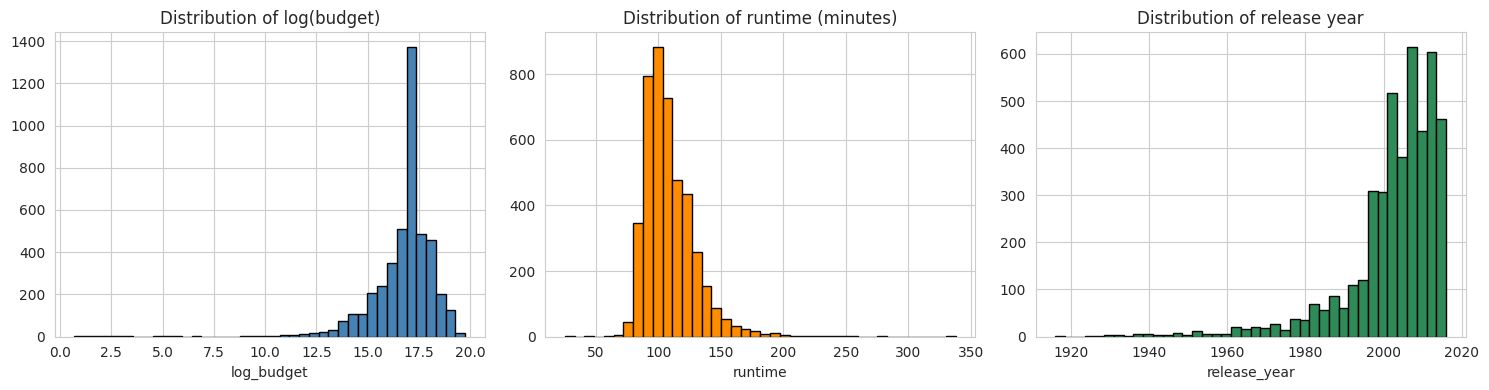

In [15]:
# Distributions of the main numeric predictors
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df["log_budget"], bins=40, color="steelblue", edgecolor="black")
axes[0].set_title("Distribution of log(budget)")
axes[0].set_xlabel("log_budget")

axes[1].hist(df["runtime"], bins=40, color="darkorange", edgecolor="black")
axes[1].set_title("Distribution of runtime (minutes)")
axes[1].set_xlabel("runtime")

axes[2].hist(df["release_year"], bins=40, color="seagreen", edgecolor="black")
axes[2].set_title("Distribution of release year")
axes[2].set_xlabel("release_year")

plt.tight_layout()
plt.show()

In [16]:
# How many movies share the exact median budget?
median_budget = df["budget"].median()
n_at_median = (df["budget"] == median_budget).sum()
print(f"Median budget: {median_budget:,.0f}")
print(f"Movies at exactly that value: {n_at_median}")
print(f"That's {n_at_median / len(df):.1%} of the dataset")

Median budget: 23,000,000
Movies at exactly that value: 764
That's 17.4% of the dataset


**Observations:**  
- `log_budget`  is concentrated between roughly 13 and 19, with a sharp spike at log_budget ≈ 17. This spike is an artifact of median imputation: 764 movies (17.4% of the dataset) had budget = 0 in the original data and were all filled with the same median value of $23,000,000.
- `runtime`  is approximately normal, peaking around 95–100 minutes with a slight right tail. A few outliers exceed 200 minutes.
- `release_year`  is strongly skewed toward recent decades. The dataset is dominated by post-2000 films, with the densest years around 2010–2015. Pre-1980 movies are very rare, so the model's reliable range is essentially modern cinema.

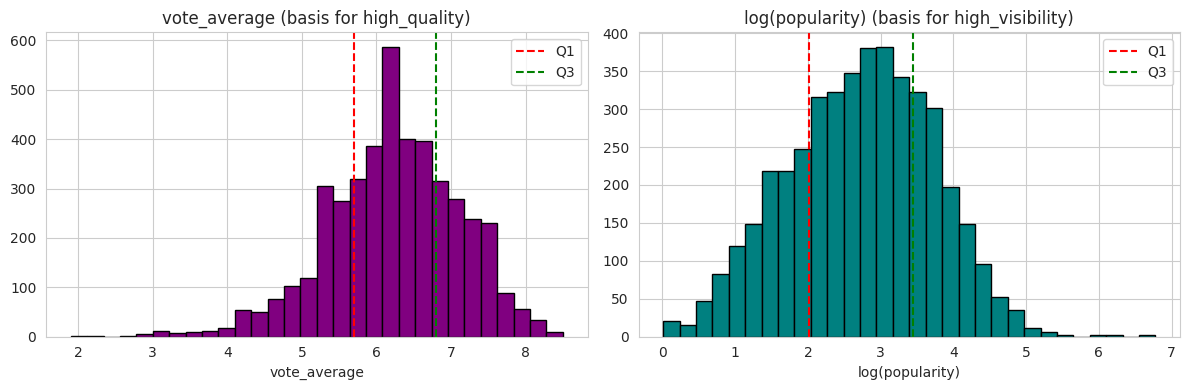

In [17]:
# Distributions of the raw outcome variables (before binarization)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["vote_average"], bins=30, color="purple", edgecolor="black")
axes[0].axvline(df["vote_average"].quantile(0.25), color="red", linestyle="--", label="Q1")
axes[0].axvline(df["vote_average"].quantile(0.75), color="green", linestyle="--", label="Q3")
axes[0].set_title("vote_average (basis for high_quality)")
axes[0].set_xlabel("vote_average")
axes[0].legend()

# popularity is highly skewed → use log scale for visualization only
axes[1].hist(np.log1p(df["popularity"]), bins=30, color="teal", edgecolor="black")
axes[1].axvline(np.log1p(df["popularity"].quantile(0.25)), color="red", linestyle="--", label="Q1")
axes[1].axvline(np.log1p(df["popularity"].quantile(0.75)), color="green", linestyle="--", label="Q3")
axes[1].set_title("log(popularity) (basis for high_visibility)")
axes[1].set_xlabel("log(popularity)")
axes[1].legend()

plt.tight_layout()
plt.show()

In [18]:
# Exact count of movies in the tallest vote_average bin
import numpy as np
counts, bin_edges = np.histogram(df["vote_average"], bins=30)
peak_idx = counts.argmax()
print(f"Tallest bin: {bin_edges[peak_idx]:.2f} to {bin_edges[peak_idx+1]:.2f}")
print(f"Movies in that bin: {counts[peak_idx]}")

Tallest bin: 6.08 to 6.30
Movies in that bin: 587


The dashed lines mark the Q1 and Q3 thresholds used to define the binary outcomes.

- `vote_average` is roughly bell-shaped but shows a pronounced spike near between 6.08 to 6.30, where 587 movies cluster in a single narrow bin. Combined with the fact that Q1 and Q3 sit only ~1.1 points apart on a 10-point scale (≈ 5.7 vs. 6.8), this confirms the limitation noted in preprocessing: high- and low-quality films are numerically very close, which we expect to make classification harder.
- `log(popularity)` is nearly normal once log-transformed, with Q1 and Q3 well-separated. The high- and low-visibility classes are therefore far more distinguishable than the high- and low-quality classes. We should expect the visibility model to outperform the quality model.

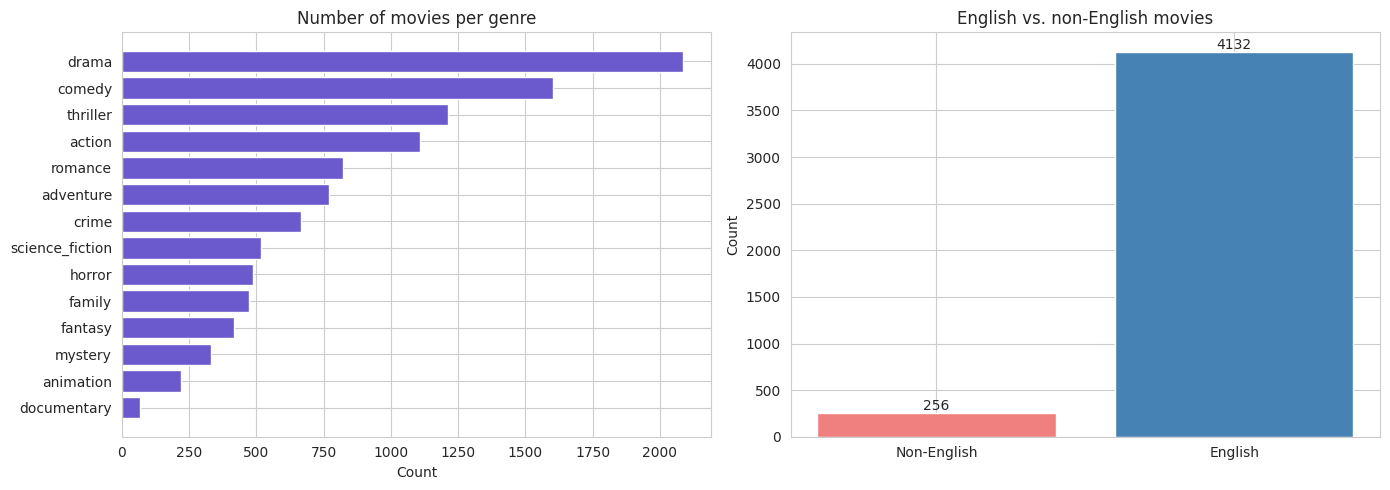


English-language share: 94.2%


In [19]:
# Frequency of binary features: genres and is_english
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

genre_counts = df[genre_cols].sum().sort_values(ascending=True)
axes[0].barh(genre_counts.index.str.replace("genre_", ""), genre_counts.values, color="slateblue")
axes[0].set_title("Number of movies per genre")
axes[0].set_xlabel("Count")

lang_counts = df["is_english"].value_counts().sort_index()  # 0 first, then 1
axes[1].bar(["Non-English", "English"], lang_counts.values, color=["lightcoral", "steelblue"])
axes[1].set_title("English vs. non-English movies")
axes[1].set_ylabel("Count")
for i, v in enumerate(lang_counts.values):
    axes[1].text(i, v, str(v), ha="center", va="bottom")

plt.tight_layout()
plt.show()

print(f"\nEnglish-language share: {df['is_english'].mean():.1%}")

**Observations:**  
- Genres: drama is the most common (>2,000 movies), followed by comedy, thriller, and action. Documentary and animation are the rarest. The imbalance is significant as drama has roughly 30× more movies than documentary, so any model coefficient for documentary will be much less reliable than for drama.

- Language: the dataset is overwhelmingly English (4,132 vs. 256 non-English). With ~94% of movies in the majority class, is_english carries very little information and we should expect this feature to have a small effect.

## 2. Target variable balance

Because we created the targets from quartiles (top 25% vs. bottom 25%, with the middle dropped), each target should be roughly balanced within its respective modeling subset.

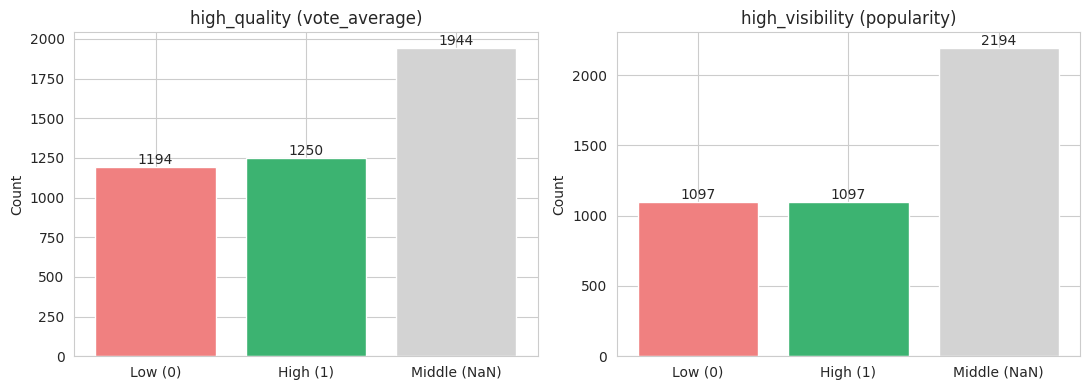

high_quality: 2444 usable rows, 51.1% positive class
high_visibility: 2194 usable rows, 50.0% positive class


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, target, title in zip(
    axes,
    ["high_quality", "high_visibility"],
    ["high_quality (vote_average)", "high_visibility (popularity)"]
):
    counts = df[target].value_counts(dropna=False).sort_index()
    labels = ["Low (0)", "High (1)", "Middle (NaN)"]
    values = [counts.get(0.0, 0), counts.get(1.0, 0), df[target].isna().sum()]
    bars = ax.bar(labels, values, color=["lightcoral", "mediumseagreen", "lightgray"])
    ax.set_title(title)
    ax.set_ylabel("Count")
    for b, v in zip(bars, values):
        ax.text(b.get_x() + b.get_width() / 2, v, str(v), ha="center", va="bottom")

plt.tight_layout()
plt.show()

for target in ["high_quality", "high_visibility"]:
    sub = df.dropna(subset=[target])
    pos = (sub[target] == 1).mean()
    print(f"{target}: {sub.shape[0]} usable rows, {pos:.1%} positive class")

## 3. Bivariate analysis: features vs. targets

We now examine how each predictor relates to our two outcomes. For numeric features we use boxplots; for binary features (genres, language) we compare the share of high-class movies in each group.

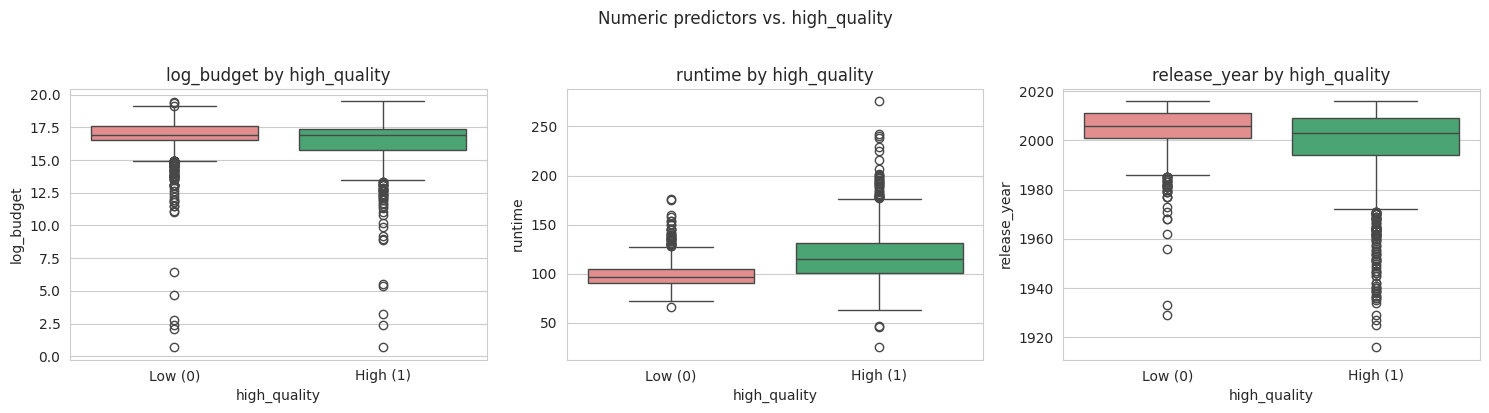

In [21]:
# Numeric features vs. high_quality
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
subset = df.dropna(subset=["high_quality"]).copy()
subset["high_quality"] = subset["high_quality"].astype(int)

for ax, feat in zip(axes, numeric_features):
    sns.boxplot(data=subset, x="high_quality", y=feat, ax=ax,
                hue="high_quality", palette=["lightcoral", "mediumseagreen"],
                legend=False)
    ax.set_title(f"{feat} by high_quality")
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Low (0)", "High (1)"])

plt.suptitle("Numeric predictors vs. high_quality", y=1.02)
plt.tight_layout()
plt.show()

**Observations:**
- **log_budget**: low- and high-quality movies have nearly identical budget
distributions. Budget does not meaningfully separate the two classes which means
quality is not budget-driven.
- **runtime**: high-quality movies are noticeably longer, with median runtime
around 115 minutes vs. ~95 for low-quality movies. Longer films tend to be
rated higher, possibly because more substantial movies attract more invested
viewers.
- **release_year**: high-quality movies skew slightly older and have a much
longer tail extending back to the 1920s, while low-quality movies are
concentrated in recent years.

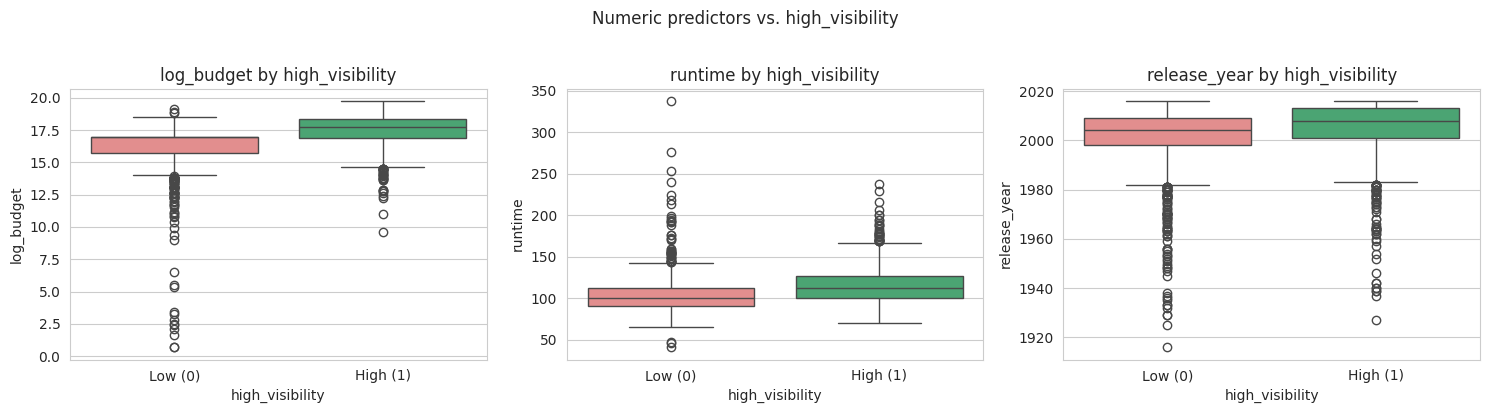

In [22]:
# Numeric features vs. high_visibility
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
subset = df.dropna(subset=["high_visibility"]).copy()
subset["high_visibility"] = subset["high_visibility"].astype(int)

for ax, feat in zip(axes, numeric_features):
    sns.boxplot(data=subset, x="high_visibility", y=feat, ax=ax,
                hue="high_visibility", palette=["lightcoral", "mediumseagreen"],
                legend=False)
    ax.set_title(f"{feat} by high_visibility")
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Low (0)", "High (1)"])


plt.suptitle("Numeric predictors vs. high_visibility", y=1.02)
plt.tight_layout()
plt.show()

**Observations:**

- **`log_budget`**: clear separation between the two classes. High-visibility movies have noticeably larger budgets (median around 17.5) than low-visibility movies (median around 16). This is the strongest budget signal seen so far: popular movies are expensive movies.
- **`runtime`**: High-visibility movies are slightly longer (median ~110 minutes vs. ~95 for low-visibility), but the difference is smaller than for budget. Runtime matters, but probably less than money.
- **`release_year`**: High-visibility movies skew more recent and are tightly concentrated in the 2000s and 2010s, while low-visibility movies have a much longer tail going back to the 1920s. This makes sense Aas popularity decays over time as audiences move on, so older films are less "visible" in current TMDB activity.

## 4. Genre breakdowns

A closer look at how the raw outcome variables (vote_average and popularity) vary across genres.

In [23]:
# Average vote_average and popularity per genre
genre_summary = []
for col in genre_cols:
    sub = df[df[col] == 1]
    genre_summary.append({
        "genre": col.replace("genre_", ""),
        "n_movies": len(sub),
        "mean_vote_average": sub["vote_average"].mean(),
        "mean_popularity": sub["popularity"].mean(),
        "median_log_budget": sub["log_budget"].median()
    })

genre_summary_df = pd.DataFrame(genre_summary).sort_values("mean_vote_average", ascending=False)
genre_summary_df.round(2)

,genre,n_movies,mean_vote_average,mean_popularity,median_log_budget
5,documentary,68,6.92,6.17,16.26
6,drama,2087,6.51,19.49,16.95
2,animation,221,6.42,41.03,17.97
4,crime,665,6.35,23.89,16.95
11,romance,823,6.28,17.29,16.95
10,mystery,331,6.27,25.81,16.95
1,adventure,770,6.17,40.26,17.73
7,family,473,6.11,30.12,17.48
8,fantasy,416,6.10,37.07,17.71
13,thriller,1211,6.10,25.70,16.95


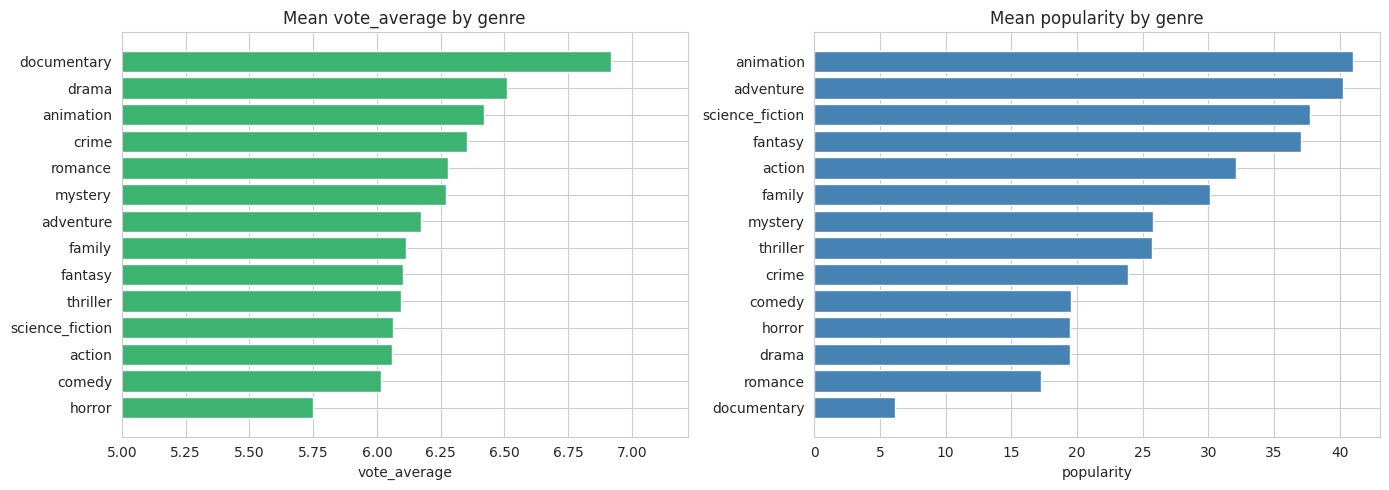

In [24]:
# Side-by-side bar charts: mean rating and mean popularity per genre
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

g1 = genre_summary_df.sort_values("mean_vote_average")
axes[0].barh(g1["genre"], g1["mean_vote_average"], color="mediumseagreen")
axes[0].set_title("Mean vote_average by genre")
axes[0].set_xlabel("vote_average")
axes[0].set_xlim(5, g1["mean_vote_average"].max() + 0.3)

g2 = genre_summary_df.sort_values("mean_popularity")
axes[1].barh(g2["genre"], g2["mean_popularity"], color="steelblue")
axes[1].set_title("Mean popularity by genre")
axes[1].set_xlabel("popularity")

plt.tight_layout()
plt.show()

**Observations:**

- **Quality leaders (left)**: Documentary, drama, animation, and crime are the top-rated genres. These tend to be more substantive or character-driven films that attract viewers who care enough to rate them favorably.
- **Visibility leaders (right)**: animation, adventure, science fiction, fantasy, and action dominate popularity. These are the big-budget blockbuster genres designed for mass appeal.
- **The two rankings are almost inverted for several genres**: Documentary is the *highest*-rated but the *least* popular. Drama ranks 2nd in quality but near the bottom in popularity. Conversely, action ranks near the bottom in quality but in the top half for popularity. Adventure and science fiction follow the same pattern.
- **Animation is the only genre that scores high on both axes** — likely driven by major studio releases (Pixar, Disney, DreamWorks) that combine craft with mass-market appeal.
- **This confirms that quality and visibility capture genuinely different signals**, justifying our decision to model them as two separate prediction problems rather than collapsing them into one "success" target.

## 5. Correlations and multicollinearity

Before modeling, we check for strong correlations among predictors. High multicollinearity can destabilize logistic regression coefficients and make interpretation unreliable.

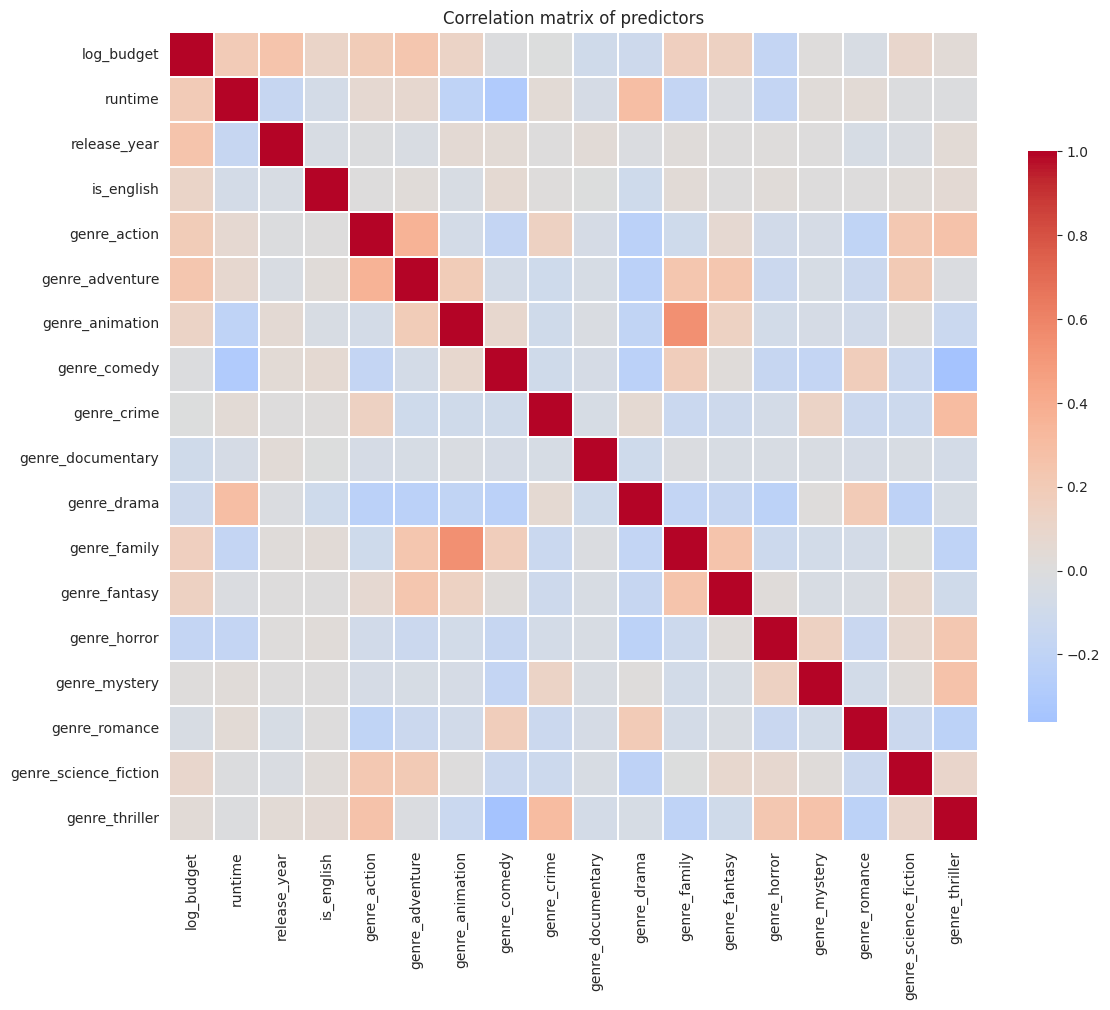

In [25]:
# Correlation matrix on all predictors
feature_cols = numeric_features + ["is_english"] + genre_cols
corr_matrix = df[feature_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=False, cmap="coolwarm", center=0,
            square=True, linewidths=0.3, cbar_kws={"shrink": 0.7}, ax=ax)
ax.set_title("Correlation matrix of predictors")
plt.tight_layout()
plt.show()

In [26]:
# Surface the strongest pairwise correlations (excluding self-correlations)
corr_pairs = (
    corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    .stack()
    .reset_index()
    .rename(columns={"level_0": "feature_1", "level_1": "feature_2", 0: "correlation"})
)
corr_pairs["abs_corr"] = corr_pairs["correlation"].abs()
corr_pairs.sort_values("abs_corr", ascending=False).head(10).round(3)

,feature_1,feature_2,correlation,abs_corr
91,genre_animation,genre_family,0.545,0.545
62,genre_action,genre_adventure,0.361,0.361
107,genre_comedy,genre_thriller,-0.361,0.361
116,genre_crime,genre_thriller,0.306,0.306
25,runtime,genre_drama,0.289,0.289
22,runtime,genre_comedy,-0.288,0.288
74,genre_action,genre_thriller,0.262,0.262
149,genre_mystery,genre_thriller,0.262,0.262
1,log_budget,release_year,0.255,0.255
132,genre_family,genre_fantasy,0.254,0.254


**Observations:**

- The matrix is dominated by pale colors, meaning most predictor pairs are weakly correlated. This is good as multicollinearity won't destabilize the logistic regression.
- The strongest positive correlation is between `genre_animation` and `genre_family` (~0.5), reflecting the natural overlap between animated films and family-oriented content.
- Other notable positive correlations are `genre_action`/`genre_adventure` and `genre_fantasy`/`genre_adventure`, all reflecting genre co-occurrence in blockbuster franchises.
- `runtime` is mildly positively correlated with drama and mildly negatively with comedy. Dramas tend to be longer films, comedies shorter.
- All correlations stay below 0.5 in absolute value, so no pair is severe enough to require dropping a feature. The VIF check below will confirm this more formally.

In [27]:
# Variance Inflation Factor (VIF) — a more formal multicollinearity check
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

X = add_constant(df[feature_cols])
vif = pd.DataFrame({
    "feature": X.columns,
    "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})
vif = vif[vif["feature"] != "const"].sort_values("VIF", ascending=False)
vif.round(2)

,feature,VIF
12,genre_family,1.65
11,genre_drama,1.58
8,genre_comedy,1.53
18,genre_thriller,1.53
7,genre_animation,1.52
5,genre_action,1.50
2,runtime,1.42
6,genre_adventure,1.42
14,genre_horror,1.38
1,log_budget,1.38


**Observations:**

- All VIF values fall between 1.05 and 1.65, well below the common warning threshold of 5. No feature is dangerously collinear with the others.
- The highest VIF is `genre_family` (1.65), reflecting its overlap with `genre_animation` seen in the heatmap. The lowest is `is_english` (1.05), which is essentially independent of every other predictor — consistent with its lopsided distribution.
- This confirms that all features can safely remain in the model without destabilizing the logistic regression coefficients. No feature engineering or dropping is required for multicollinearity reasons.

# Classification Modeling: high_quality

---



---



Following the EDA, we now build classification models to predict `high_quality` (top quartile of `vote_average` vs. bottom quartile). We start with **logistic regression** because it produces signed coefficients with p-values, giving us a clear and interpretable answer to the question *"which features predict high audience ratings?"* which is the first research question of our proposal. A decision tree model will follow in the next section to capture nonlinear patterns and interactions that logistic regression cannot.

## Setup and train/test split

We use only the rows where `high_quality` is defined (top + bottom quartiles), and split them 80/20 into a training set (used to fit the model) and a held-out test set (used only for final evaluation). `random_state=42` makes the split reproducible. We also stratify on the target so the training and test sets keep the same class balance as the full subset.

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
import statsmodels.api as sm

# Define feature columns (same as in EDA)
feature_cols = numeric_features + ["is_english"] + genre_cols

# Keep only rows where high_quality is defined (top + bottom quartiles)
df_q = df.dropna(subset=["high_quality"]).copy()
df_q["high_quality"] = df_q["high_quality"].astype(int)

X = df_q[feature_cols]
y = df_q["high_quality"]

# 80/20 train/test split, stratified on the target to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]} rows  ({y_train.mean():.1%} positive class)")
print(f"Test:  {X_test.shape[0]} rows  ({y_test.mean():.1%} positive class)")

Train: 1955 rows  (51.2% positive class)
Test:  489 rows  (51.1% positive class)


## Fit the logistic regression

We standardize the numeric features (mean 0, standard deviation 1) before fitting. This puts `log_budget`, `runtime`, and `release_year` on a comparable scale so their coefficients can be interpreted side by side. Genre dummies and `is_english` are already on a 0/1 scale and don't need scaling. We use scikit-learn for prediction and a parallel statsmodels fit so we can read off p-values for each coefficient.

In [29]:
# Standardize the numeric features only (genre dummies and is_english stay 0/1)
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()
X_train_scaled[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test_scaled[numeric_features]  = scaler.transform(X_test[numeric_features])

# Fit the logistic regression
logreg_q = LogisticRegression(max_iter=1000, random_state=42)
logreg_q.fit(X_train_scaled, y_train)

# Parallel statsmodels fit for p-values
X_train_sm = sm.add_constant(X_train_scaled)
logit_sm_q = sm.Logit(y_train, X_train_sm).fit(disp=0)

print("Model fitted successfully.")

Model fitted successfully.


## Evaluate on the test set

We compute four metrics on the held-out test set:
- **Accuracy**: how often the prediction is right (compare against the ~50% naive baseline).
- **Precision**: of movies predicted as high-quality, how many actually are.
- **Recall**: of actually high-quality movies, how many we correctly catch.
- **F1**: the harmonic mean of precision and recall, useful as a single summary number.

We also display the confusion matrix to see exactly where the model gets things right and wrong.

In [30]:
# Predict on the test set
y_pred = logreg_q.predict(X_test_scaled)

# Compute metrics
metrics = {
    "Accuracy":  accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall":    recall_score(y_test, y_pred),
    "F1 score":  f1_score(y_test, y_pred),
}

for name, value in metrics.items():
    print(f"{name:10s}: {value:.3f}")

print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=["Low (0)", "High (1)"]))

Accuracy  : 0.814
Precision : 0.819
Recall    : 0.816
F1 score  : 0.818

Classification report:
              precision    recall  f1-score   support

     Low (0)       0.81      0.81      0.81       239
    High (1)       0.82      0.82      0.82       250

    accuracy                           0.81       489
   macro avg       0.81      0.81      0.81       489
weighted avg       0.81      0.81      0.81       489



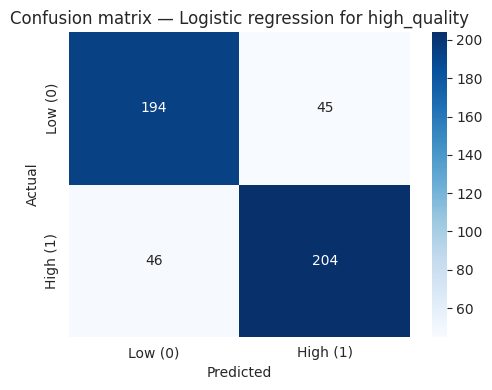

In [31]:
# Confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Low (0)", "High (1)"],
            yticklabels=["Low (0)", "High (1)"], ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion matrix — Logistic regression for high_quality")
plt.tight_layout()
plt.show()

## Interpret the coefficients

Logistic regression's main strength is interpretability. Each predictor has a **coefficient** (positive = pushes probability toward "high quality", negative = pushes toward "low quality") and a **p-value** (small p-value means the effect is statistically significant, i.e. unlikely to be random noise).

Because numeric features were standardized, their coefficients can be compared on the same scale. Genre coefficients should be read as "the effect of being tagged with this genre, controlling for everything else."

In [32]:
# Build a coefficient table with p-values from statsmodels
coef_df = pd.DataFrame({
    "feature": X_train_sm.columns,
    "coefficient": logit_sm_q.params.values,
    "p_value": logit_sm_q.pvalues.values,
})

# Mark significance
def stars(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return ""
coef_df["sig"] = coef_df["p_value"].apply(stars)

# Sort by absolute coefficient size (largest effect first), keep const at the top
coef_df_sorted = pd.concat([
    coef_df[coef_df["feature"] == "const"],
    coef_df[coef_df["feature"] != "const"].reindex(
        coef_df[coef_df["feature"] != "const"]["coefficient"].abs().sort_values(ascending=False).index
    )
])
coef_df_sorted.round(3).reset_index(drop=True)

,feature,coefficient,p_value,sig
0,const,1.492,0.000,***
1,genre_documentary,4.962,0.000,***
2,genre_animation,2.533,0.000,***
3,runtime,1.537,0.000,***
4,is_english,-1.220,0.000,***
5,genre_drama,1.139,0.000,***
6,genre_horror,-0.969,0.000,***
7,genre_comedy,-0.845,0.000,***
8,release_year,-0.777,0.000,***
9,genre_action,-0.767,0.000,***


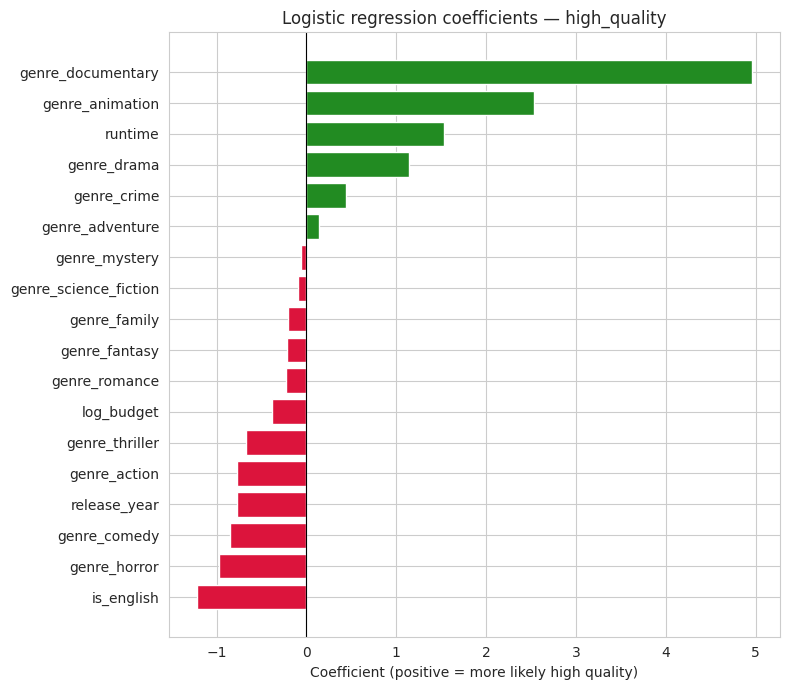

In [33]:
# Visualize coefficients
plot_df = coef_df[coef_df["feature"] != "const"].sort_values("coefficient")
colors = ["crimson" if c < 0 else "forestgreen" for c in plot_df["coefficient"]]

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(plot_df["feature"], plot_df["coefficient"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Logistic regression coefficients — high_quality")
ax.set_xlabel("Coefficient (positive = more likely high quality)")
plt.tight_layout()
plt.show()

# Decision Tree: high_quality

We now fit a **decision tree** on the same `high_quality` target. While logistic regression assumes each predictor's effect is linear and additive, a decision tree captures **nonlinear effects** and **interactions** between features.

We reuse the same train/test split as the logistic regression so the two models are directly comparable. We do **not** standardize features for the tree (trees split on raw values, so scaling has no effect on the result).

## Fit the decision tree

We limit `max_depth=5` to prevent the tree from memorizing the training data.  An unconstrained tree would grow until every training row is perfectly classified, which produces a model that fails on new data (overfitting). Depth 5 is a common starting point that balances expressiveness against overfitting. `min_samples_leaf=20` is a second guardrail: every terminal leaf must contain at least 20 movies, so no decision is made on the basis of just a handful of cases.

In [34]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Fit the decision tree on the unscaled features (trees don't need scaling)
tree_q = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=20,
    random_state=42
)
tree_q.fit(X_train, y_train)

print("Decision tree fitted.")
print(f"Tree depth: {tree_q.get_depth()}")
print(f"Number of leaves: {tree_q.get_n_leaves()}")

Decision tree fitted.
Tree depth: 5
Number of leaves: 30


## Evaluate on the test set

We compute the same four metrics as before so the tree's performance is directly comparable to the logistic regression's.

In [35]:
# Predict and evaluate
y_pred_tree = tree_q.predict(X_test)

metrics_tree = {
    "Accuracy":  accuracy_score(y_test, y_pred_tree),
    "Precision": precision_score(y_test, y_pred_tree),
    "Recall":    recall_score(y_test, y_pred_tree),
    "F1 score":  f1_score(y_test, y_pred_tree),
}

for name, value in metrics_tree.items():
    print(f"{name:10s}: {value:.3f}")

print("\nClassification report:")
print(classification_report(y_test, y_pred_tree, target_names=["Low (0)", "High (1)"]))

Accuracy  : 0.744
Precision : 0.736
Recall    : 0.780
F1 score  : 0.757

Classification report:
              precision    recall  f1-score   support

     Low (0)       0.75      0.71      0.73       239
    High (1)       0.74      0.78      0.76       250

    accuracy                           0.74       489
   macro avg       0.75      0.74      0.74       489
weighted avg       0.74      0.74      0.74       489



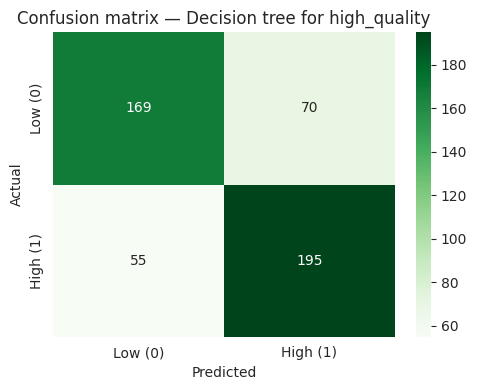

In [36]:
# Confusion matrix
cm_tree = confusion_matrix(y_test, y_pred_tree)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_tree, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Low (0)", "High (1)"],
            yticklabels=["Low (0)", "High (1)"], ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion matrix — Decision tree for high_quality")
plt.tight_layout()
plt.show()

## Feature importances

Decision trees don't produce signed coefficients with p-values. Instead they report **feature importance**: a number between 0 and 1 indicating how much each feature contributed to splits, weighted by how many movies were affected. All importances sum to 1. Importance tells you *how much a feature matters*, but not *in which direction* it pushes the prediction. For that, we cross-check against the logistic regression coefficients.

In [37]:
# Feature importance table
importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": tree_q.feature_importances_,
}).sort_values("importance", ascending=False)

importance_df.round(3).reset_index(drop=True)

,feature,importance
0,runtime,0.528
1,log_budget,0.148
2,genre_drama,0.146
3,release_year,0.080
4,genre_animation,0.049
5,genre_thriller,0.032
6,genre_comedy,0.010
7,genre_science_fiction,0.006
8,genre_romance,0.001
9,is_english,0.000


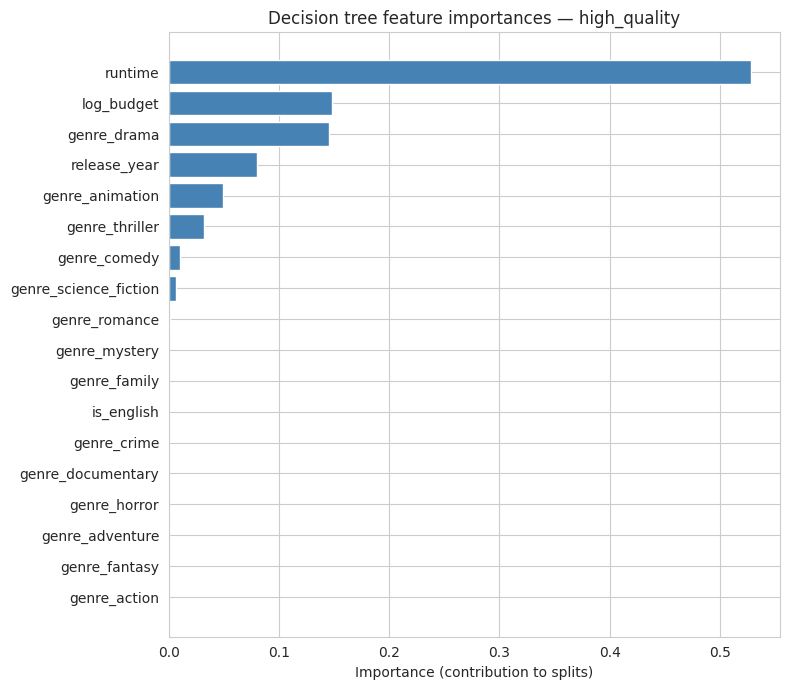

In [38]:
# Plot the feature importances
plot_imp = importance_df.sort_values("importance")
fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(plot_imp["feature"], plot_imp["importance"], color="steelblue")
ax.set_title("Decision tree feature importances — high_quality")
ax.set_xlabel("Importance (contribution to splits)")
plt.tight_layout()
plt.show()

## Visualize the tree

A tree diagram shows exactly how the model decides. Each box shows the splitting rule, the number of samples reaching that node, and the predicted class. Reading the tree from top to bottom traces the model's reasoning and reveals interactions between features that logistic regression cannot capture.

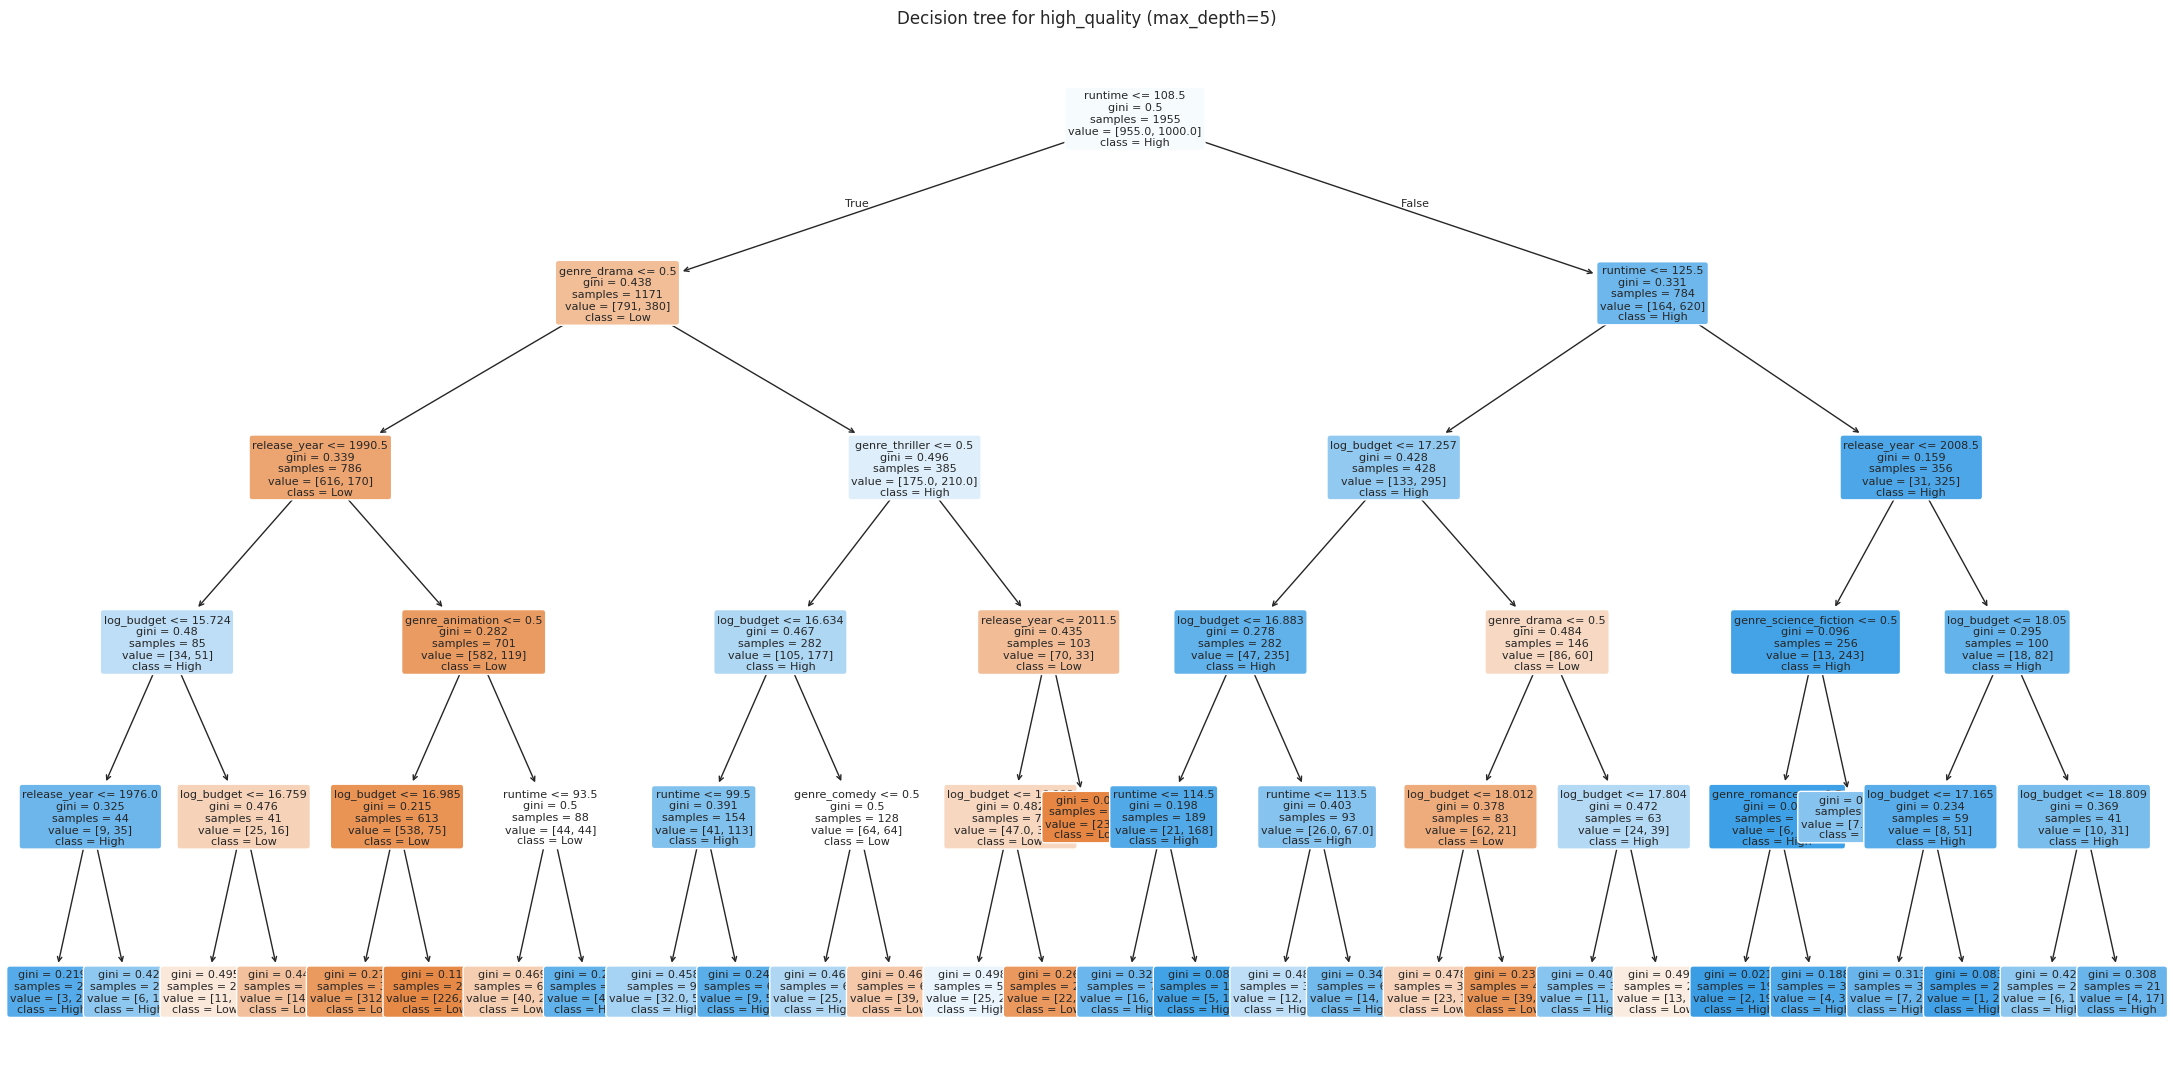

In [39]:
# Plot the full tree
fig, ax = plt.subplots(figsize=(22, 11))
plot_tree(
    tree_q,
    feature_names=feature_cols,
    class_names=["Low", "High"],
    filled=True,
    rounded=True,
    fontsize=8,
    ax=ax
)
ax.set_title("Decision tree for high_quality (max_depth=5)")
plt.tight_layout()
plt.show()

## Compare logistic regression and decision tree

A side-by-side comparison of the two models' performance. The proposal calls for evaluating both. This comparison addresses *whether a more flexible model captures patterns that the linear model misses, or whether the linear story is essentially the full story*.

In [40]:
# Build a comparison table of all four metrics
comparison = pd.DataFrame({
    "Logistic regression": [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred),
    ],
    "Decision tree": [
        accuracy_score(y_test, y_pred_tree),
        precision_score(y_test, y_pred_tree),
        recall_score(y_test, y_pred_tree),
        f1_score(y_test, y_pred_tree),
    ],
}, index=["Accuracy", "Precision", "Recall", "F1 score"])

comparison.round(3)

,Logistic regression,Decision tree
Accuracy,0.814,0.744
Precision,0.819,0.736
Recall,0.816,0.780
F1 score,0.818,0.757


# Classification Modeling: high_visibility

---



---



We now carry out similar predictive modelling for `high_visibility`. Again, we start with **logistic regression** then use a **decision tree model**.

### Setup and train/test split

We use only the rows where `high_visibility` is defined (top + bottom quartiles), and split them 80/20 into a training set (used to fit the model) and a held-out test set (used only for final evaluation). 'random_state=42' makes the split reproducible. We also stratify on the target so the training and test sets keep the same class balance as the full subset.

In [41]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
import statsmodels.api as sm

# Define feature columns (same as in EDA)
feature_cols = numeric_features + ["is_english"] + genre_cols

# Keep only rows where high_visibility is defined (top + bottom quartiles)
df_v = df.dropna(subset=["high_visibility"]).copy()
df_v["high_visibility"] = df_v["high_visibility"].astype(int)

X = df_v[feature_cols]
y = df_v["high_visibility"]

# 80/20 train/test split, stratified on the target to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]} rows  ({y_train.mean():.1%} positive class)")
print(f"Test:  {X_test.shape[0]} rows  ({y_test.mean():.1%} positive class)")

Train: 1755 rows  (50.0% positive class)
Test:  439 rows  (49.9% positive class)


##Fit the logistic regression

We standardize the numeric features (mean 0, standard deviation 1) before fitting. This puts `log_budget`, `runtime`, and `release_year` on a comparable scale so their coefficients can be interpreted side by side. Genre dummies and `is_english` are already on a 0/1 scale and don't need scaling. We use scikit-learn for prediction and a parallel statsmodels fit so we can read off p-values for each coefficient.

In [42]:
# Standardize the numeric features only (genre dummies and is_english stay 0/1)
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()
X_train_scaled[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test_scaled[numeric_features]  = scaler.transform(X_test[numeric_features])

# Fit the logistic regression
logreg_v = LogisticRegression(max_iter=1000, random_state=42)
logreg_v.fit(X_train_scaled, y_train)

# Parallel statsmodels fit for p-values
X_train_sm = sm.add_constant(X_train_scaled)
logit_sm_v = sm.Logit(y_train, X_train_sm).fit(disp=0)

print("Model fitted successfully.")

Model fitted successfully.


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


###Evaluate on the test set
We compute four metrics on the held-out test set: accuracy, precision, recall, and F1 score. We also display the confusion matrix to see exactly where the model gets things right and wrong.

In [43]:
# Predict on the test set
y_pred = logreg_v.predict(X_test_scaled)

# Compute metrics
metrics = {
    "Accuracy":  accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall":    recall_score(y_test, y_pred),
    "F1 score":  f1_score(y_test, y_pred),
}

for name, value in metrics.items():
    print(f"{name:10s}: {value:.3f}")

print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=["Low (0)", "High (1)"]))

Accuracy  : 0.772
Precision : 0.790
Recall    : 0.740
F1 score  : 0.764

Classification report:
              precision    recall  f1-score   support

     Low (0)       0.76      0.80      0.78       220
    High (1)       0.79      0.74      0.76       219

    accuracy                           0.77       439
   macro avg       0.77      0.77      0.77       439
weighted avg       0.77      0.77      0.77       439



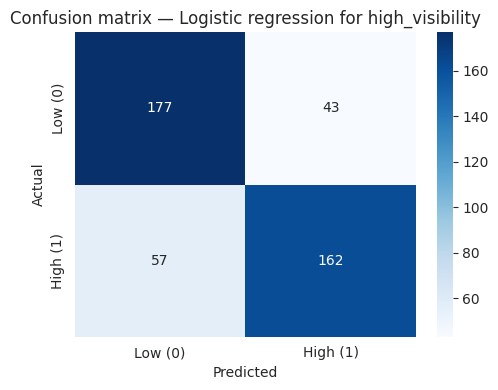

In [44]:
# Confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Low (0)", "High (1)"],
            yticklabels=["Low (0)", "High (1)"], ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion matrix — Logistic regression for high_visibility")
plt.tight_layout()
plt.show()

###Interpret the coefficients
Each predictor has a coefficient (positive = pushes probability toward "high visibility", negative = pushes toward "low visibility") and a p-value (small p-value means the effect is statistically significant, i.e. unlikely to be random noise).
Because numeric features were standardized, their coefficients can be compared on the same scale. Again, genre coefficients should be read as "the effect of being tagged with this genre, controlling for everything else."

In [45]:
# Build a coefficient table with p-values from statsmodels
coef_df = pd.DataFrame({
    "feature": X_train_sm.columns,
    "coefficient": logit_sm_v.params.values,
    "p_value": logit_sm_v.pvalues.values,
})

# Mark significance
def stars(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return ""
coef_df["sig"] = coef_df["p_value"].apply(stars)

# Sort by absolute coefficient size (largest effect first), keep const at the top
coef_df_sorted = pd.concat([
    coef_df[coef_df["feature"] == "const"],
    coef_df[coef_df["feature"] != "const"].reindex(
        coef_df[coef_df["feature"] != "const"]["coefficient"].abs().sort_values(ascending=False).index
    )
])
coef_df_sorted.round(3).reset_index(drop=True)

,feature,coefficient,p_value,sig
0,const,-1.487,0.000,***
1,genre_documentary,-29.071,1.000,
2,genre_animation,1.915,0.000,***
3,is_english,1.657,0.000,***
4,genre_fantasy,1.274,0.000,***
5,log_budget,0.925,0.000,***
6,genre_drama,-0.885,0.000,***
7,runtime,0.821,0.000,***
8,genre_adventure,0.553,0.004,**
9,genre_family,-0.544,0.037,*


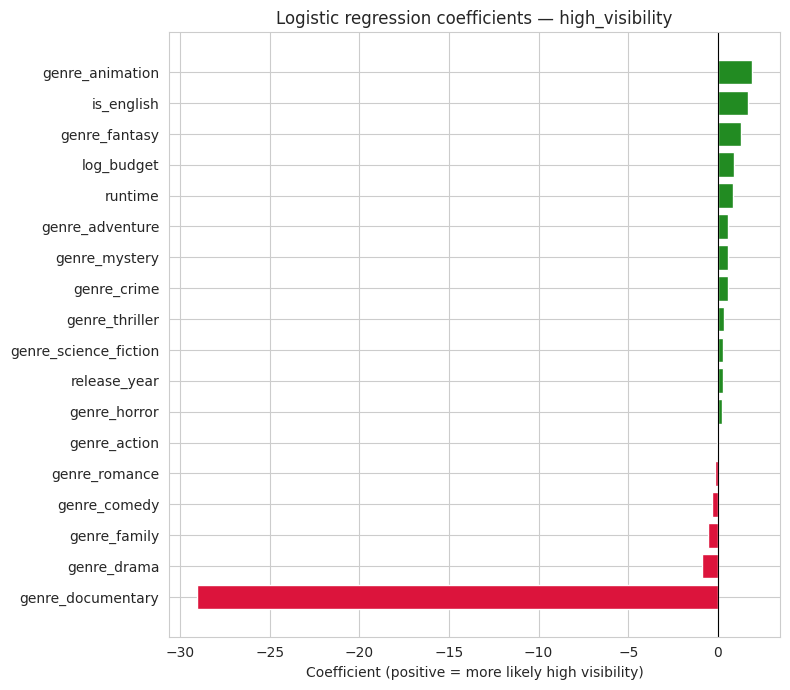

In [46]:
# Visualize coefficients
plot_df = coef_df[coef_df["feature"] != "const"].sort_values("coefficient")
colors = ["crimson" if c < 0 else "forestgreen" for c in plot_df["coefficient"]]

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(plot_df["feature"], plot_df["coefficient"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Logistic regression coefficients — high_visibility")
ax.set_xlabel("Coefficient (positive = more likely high visibility)")
plt.tight_layout()
plt.show()

##Decision Tree: high_visibility
We now fit a decision tree on the same high_visibility target. While logistic regression assumes each predictor's effect is linear and additive, a decision tree captures nonlinear effects and interactions between features.
We reuse the same train/test split as the logistic regression so the two models are directly comparable. We do not standardize features for the tree (trees split on raw values, so scaling has no effect on the result).

###Fit the decision tree
We limit max_depth=5 to prevent the tree from memorizing the training data. An unconstrained tree would grow until every training row is perfectly classified, which produces a model that fails on new data (overfitting). Depth 5 is a common starting point that balances expressiveness against overfitting. min_samples_leaf=20 is a second guardrail: every terminal leaf must contain at least 20 movies, so no decision is made on the basis of just a handful of cases.

In [47]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Fit the decision tree on the unscaled features (trees don't need scaling)
tree_v = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=20,
    random_state=42
)
tree_v.fit(X_train, y_train)

print("Decision tree fitted.")
print(f"Tree depth: {tree_v.get_depth()}")
print(f"Number of leaves: {tree_v.get_n_leaves()}")

Decision tree fitted.
Tree depth: 5
Number of leaves: 27


###Evaluate on the test set
We compute the same four metrics as before so the tree's performance is directly comparable to the logistic regression's.

In [48]:
# Predict and evaluate
y_pred_tree = tree_v.predict(X_test)

metrics_tree = {
    "Accuracy":  accuracy_score(y_test, y_pred_tree),
    "Precision": precision_score(y_test, y_pred_tree),
    "Recall":    recall_score(y_test, y_pred_tree),
    "F1 score":  f1_score(y_test, y_pred_tree),
}

for name, value in metrics_tree.items():
    print(f"{name:10s}: {value:.3f}")

print("\nClassification report:")
print(classification_report(y_test, y_pred_tree, target_names=["Low (0)", "High (1)"]))

Accuracy  : 0.811
Precision : 0.854
Recall    : 0.749
F1 score  : 0.798

Classification report:
              precision    recall  f1-score   support

     Low (0)       0.78      0.87      0.82       220
    High (1)       0.85      0.75      0.80       219

    accuracy                           0.81       439
   macro avg       0.82      0.81      0.81       439
weighted avg       0.82      0.81      0.81       439



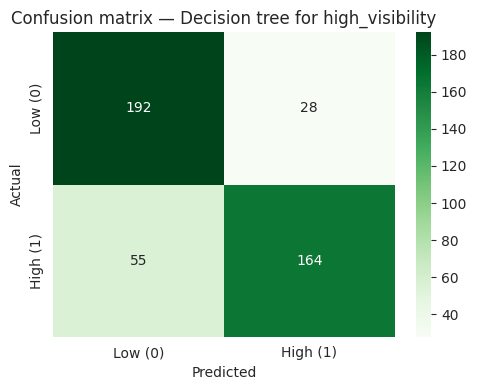

In [49]:
# Confusion matrix
cm_tree = confusion_matrix(y_test, y_pred_tree)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_tree, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Low (0)", "High (1)"],
            yticklabels=["Low (0)", "High (1)"], ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion matrix — Decision tree for high_visibility")
plt.tight_layout()
plt.show()

###Feature importances
Decision trees don't produce signed coefficients with p-values. Instead they report feature importance: a number between 0 and 1 indicating how much each feature contributed to splits, weighted by how many movies were affected. All importances sum to 1. Importance tells you how much a feature matters, but not in which direction it pushes the prediction. For that, we cross-check against the logistic regression coefficients.

In [50]:
# Feature importance table
importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": tree_v.feature_importances_,
}).sort_values("importance", ascending=False)

importance_df.round(3).reset_index(drop=True)

,feature,importance
0,log_budget,0.859
1,release_year,0.073
2,runtime,0.038
3,genre_thriller,0.018
4,genre_science_fiction,0.011
5,genre_crime,0.000
6,genre_adventure,0.000
7,genre_animation,0.000
8,genre_action,0.000
9,is_english,0.000


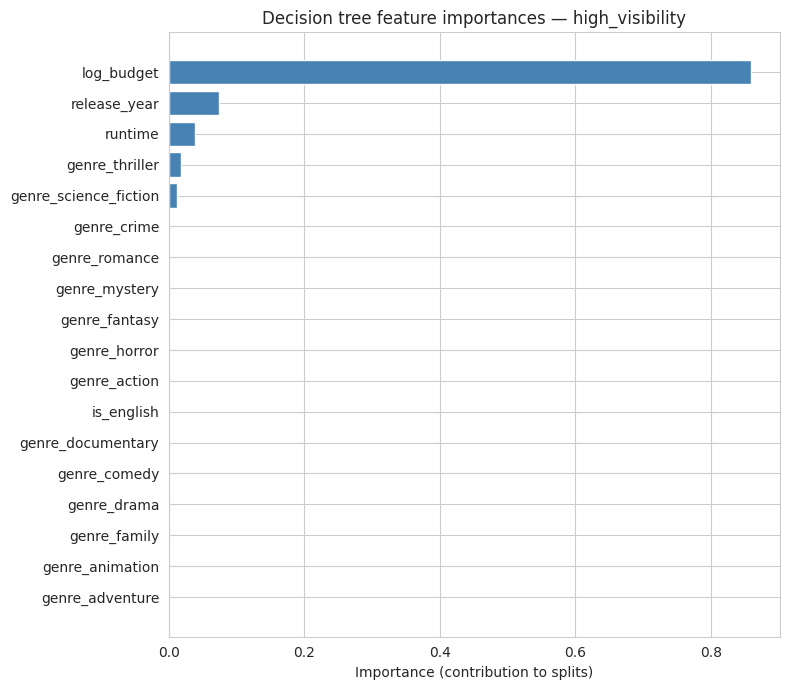

In [51]:
# Plot the feature importances
plot_imp = importance_df.sort_values("importance")
fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(plot_imp["feature"], plot_imp["importance"], color="steelblue")
ax.set_title("Decision tree feature importances — high_visibility")
ax.set_xlabel("Importance (contribution to splits)")
plt.tight_layout()
plt.show()

###Visualize the tree
A tree diagram shows exactly how the model decides. Each box shows the splitting rule, the number of samples reaching that node, and the predicted class. Reading the tree from top to bottom traces the model's reasoning and reveals interactions between features that logistic regression cannot capture.

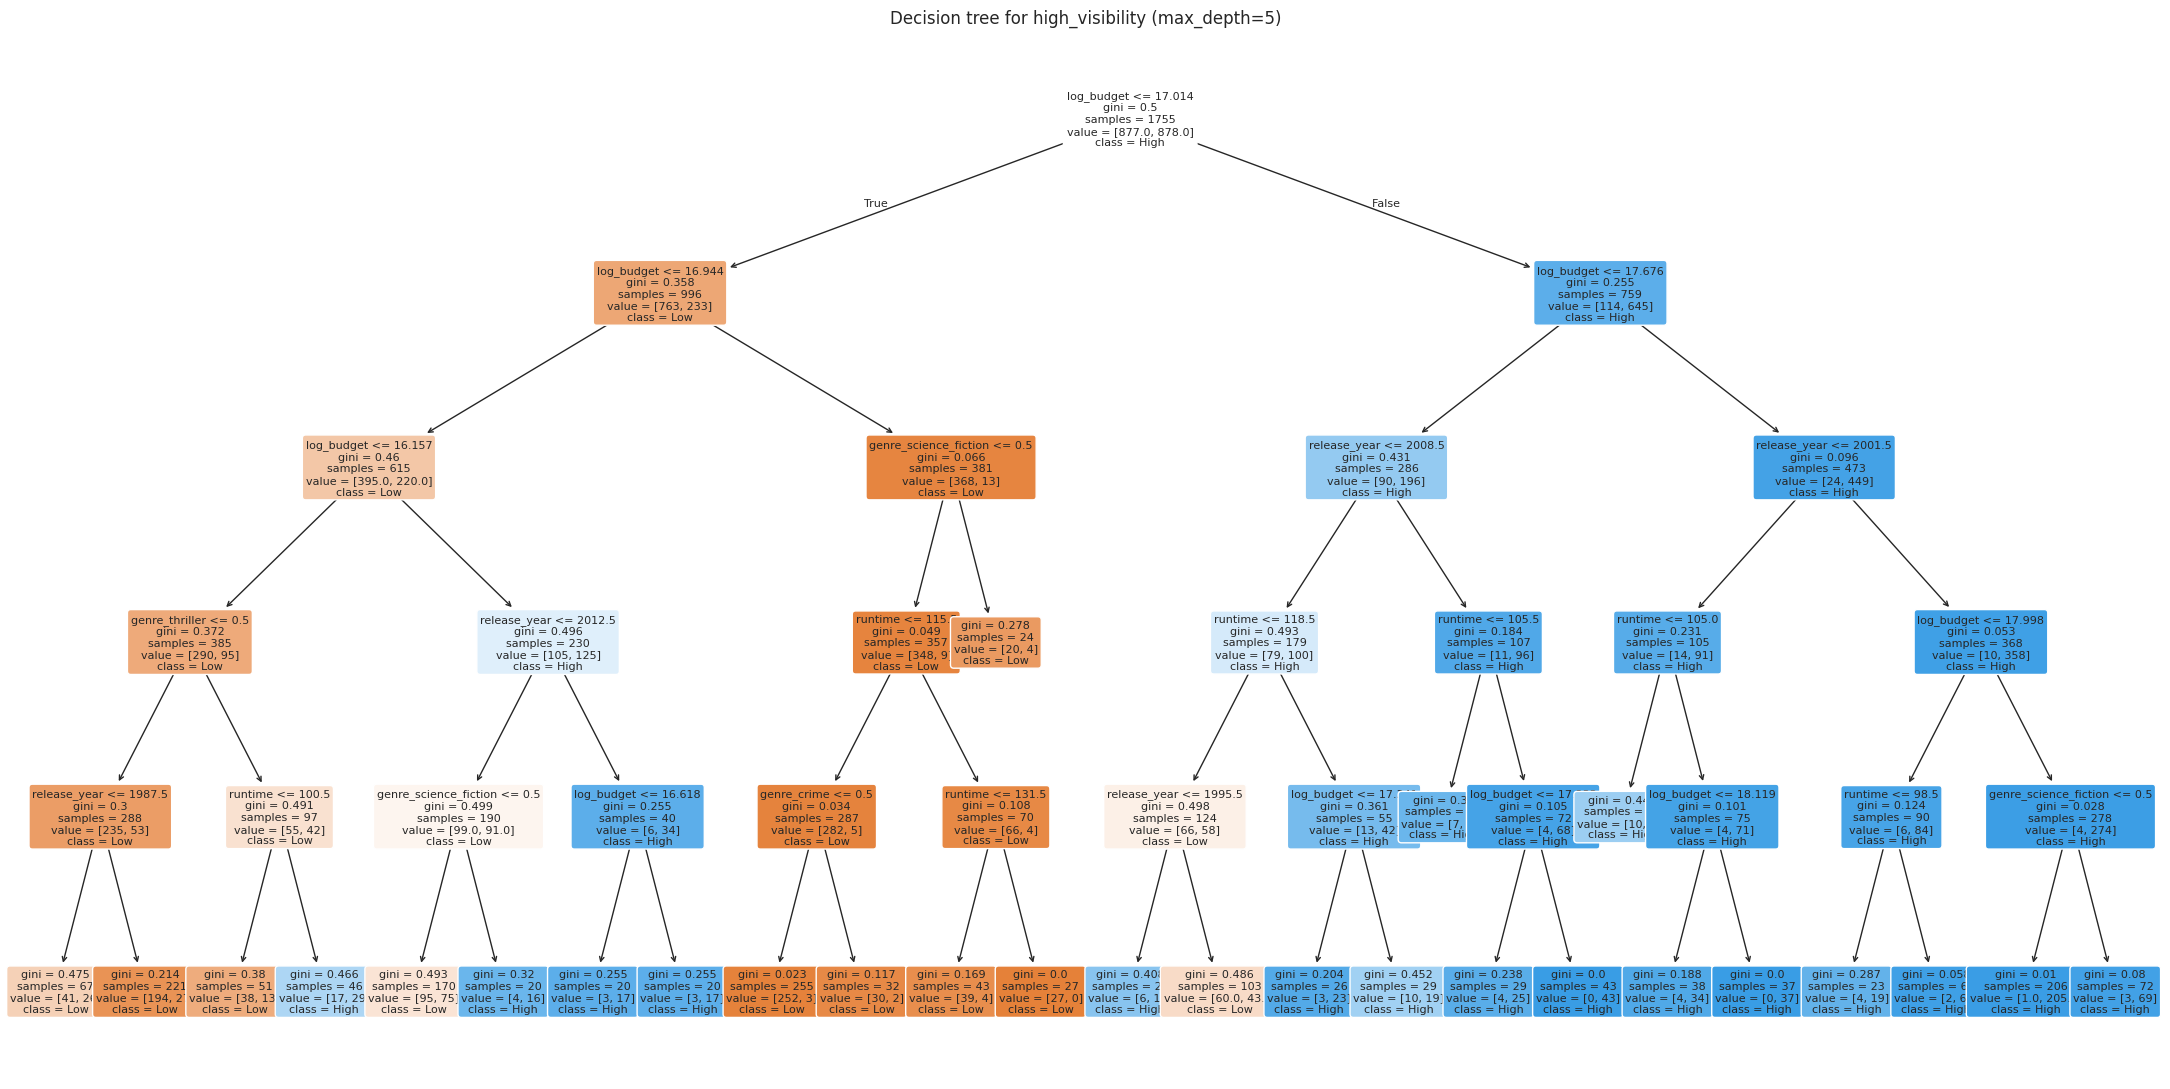

In [52]:
# Plot the full tree
fig, ax = plt.subplots(figsize=(22, 11))
plot_tree(
    tree_v,
    feature_names=feature_cols,
    class_names=["Low", "High"],
    filled=True,
    rounded=True,
    fontsize=8,
    ax=ax
)
ax.set_title("Decision tree for high_visibility (max_depth=5)")
plt.tight_layout()
plt.show()

##Compare logistic regression and decision tree
A side-by-side comparison of the two models' performance. The proposal calls for evaluating both. This comparison addresses whether a more flexible model captures patterns that the linear model misses, or whether the linear story is essentially the full story.

In [53]:
# Build a comparison table of all four metrics
comparison = pd.DataFrame({
    "Logistic regression": [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred),
    ],
    "Decision tree": [
        accuracy_score(y_test, y_pred_tree),
        precision_score(y_test, y_pred_tree),
        recall_score(y_test, y_pred_tree),
        f1_score(y_test, y_pred_tree),
    ],
}, index=["Accuracy", "Precision", "Recall", "F1 score"])

comparison.round(3)

,Logistic regression,Decision tree
Accuracy,0.772,0.811
Precision,0.790,0.854
Recall,0.740,0.749
F1 score,0.764,0.798


#Cross-model comparison

Having trained and evaluated four models — logistic regression and decision tree for each of our two outcomes — we now step back and compare them directly.

This comparative step is the core of our analysis: rather than treating the quality and visibility models as two separate exercises, we bring them together to answer our central research question of whether the structural features of a film predict quality and visibility in the same way, or whether they diverge.

We do this through two visualizations.

*   First, **ROC curves** for all four models on a single plot. Unlike accuracy or F1, the AUC (Area Under the Curve) summarizes model performance across all possible classification thresholds in a single number, where 0.5 is a random baseline and 1.0 is perfect prediction. Comparing AUC scores across the four models tells us both which algorithm performs better within each outcome, and — crucially — whether visibility is genuinely easier to predict than quality from structural features alone, as our EDA suggested it would be.
*   Second, a **unified feature importance chart** placing the logistic regression coefficients and decision tree importances for both targets side by side. This directly addresses our third sub-question: where do the predictors for quality and visibility overlap, and where do they diverge? Features that matter for both outcomes will show paired bars of similar size; features that are asymmetric (large for one outcome, near-zero for the other) are the most theoretically interesting findings, as they reveal where the logic of quality and the logic of visibility genuinely part ways.

##ROC Curves

For all four models.

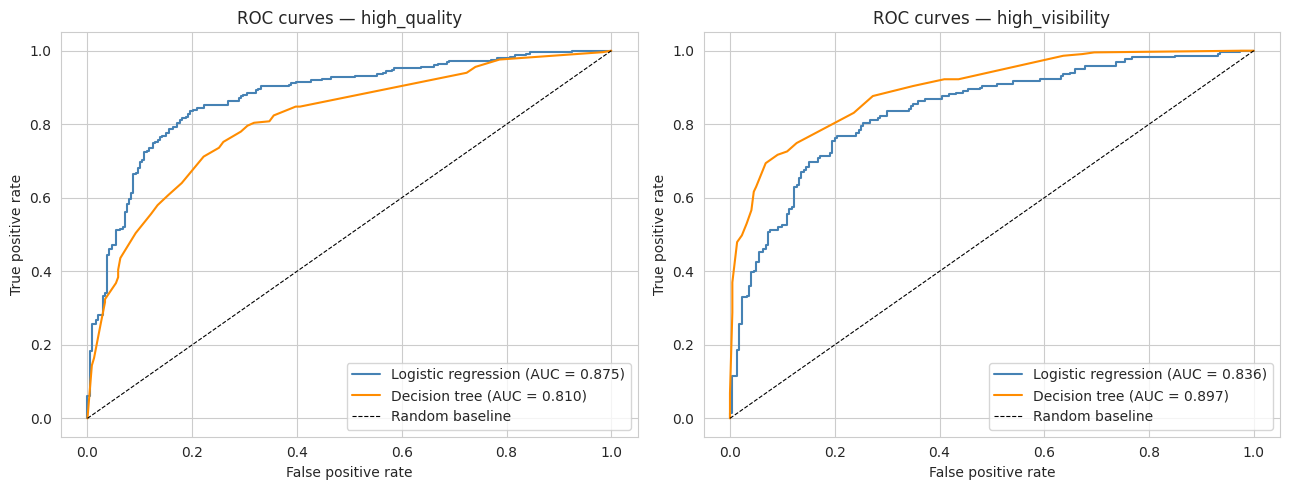

AUC summary:
  Quality    — logistic regression: 0.875 | decision tree: 0.810
  Visibility — logistic regression: 0.836 | decision tree: 0.897


In [54]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get predicted probabilities (not just class predictions) for each model
# Quality models
df_q = df.dropna(subset=["high_quality"]).copy()
df_q["high_quality"] = df_q["high_quality"].astype(int)
X_q = df_q[feature_cols]
y_q = df_q["high_quality"]
X_train_q, X_test_q, y_train_q, y_test_q = train_test_split(
    X_q, y_q, test_size=0.2, random_state=42, stratify=y_q
)
X_train_q_scaled = X_train_q.copy()
X_test_q_scaled  = X_test_q.copy()
X_train_q_scaled[numeric_features] = scaler.fit_transform(X_train_q[numeric_features])
X_test_q_scaled[numeric_features]  = scaler.transform(X_test_q[numeric_features])

prob_logreg_q  = logreg_q.predict_proba(X_test_q_scaled)[:, 1]
prob_tree_q    = tree_q.predict_proba(X_test_q)[:, 1]
prob_logreg_v  = logreg_v.predict_proba(X_test_scaled)[:, 1]
prob_tree_v    = tree_v.predict_proba(X_test)[:, 1]

# Compute ROC curves
fpr_lq, tpr_lq, _ = roc_curve(y_test_q, prob_logreg_q)
fpr_tq, tpr_tq, _ = roc_curve(y_test_q, prob_tree_q)
fpr_lv, tpr_lv, _ = roc_curve(y_test,   prob_logreg_v)
fpr_tv, tpr_tv, _ = roc_curve(y_test,   prob_tree_v)

auc_lq = auc(fpr_lq, tpr_lq)
auc_tq = auc(fpr_tq, tpr_tq)
auc_lv = auc(fpr_lv, tpr_lv)
auc_tv = auc(fpr_tv, tpr_tv)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, title, pairs in zip(
    axes,
    ["ROC curves — high_quality", "ROC curves — high_visibility"],
    [
        [(fpr_lq, tpr_lq, auc_lq, "Logistic regression", "steelblue"),
         (fpr_tq, tpr_tq, auc_tq, "Decision tree",       "darkorange")],
        [(fpr_lv, tpr_lv, auc_lv, "Logistic regression", "steelblue"),
         (fpr_tv, tpr_tv, auc_tv, "Decision tree",       "darkorange")],
    ]
):
    for fpr, tpr, auc_score, label, color in pairs:
        ax.plot(fpr, tpr, label=f"{label} (AUC = {auc_score:.3f})", color=color)
    ax.plot([0, 1], [0, 1], "k--", linewidth=0.8, label="Random baseline")
    ax.set_xlabel("False positive rate")
    ax.set_ylabel("True positive rate")
    ax.set_title(title)
    ax.legend(loc="lower right")

plt.tight_layout()
plt.show()

print("AUC summary:")
print(f"  Quality    — logistic regression: {auc_lq:.3f} | decision tree: {auc_tq:.3f}")
print(f"  Visibility — logistic regression: {auc_lv:.3f} | decision tree: {auc_tv:.3f}")

##Unified Feature Comparison

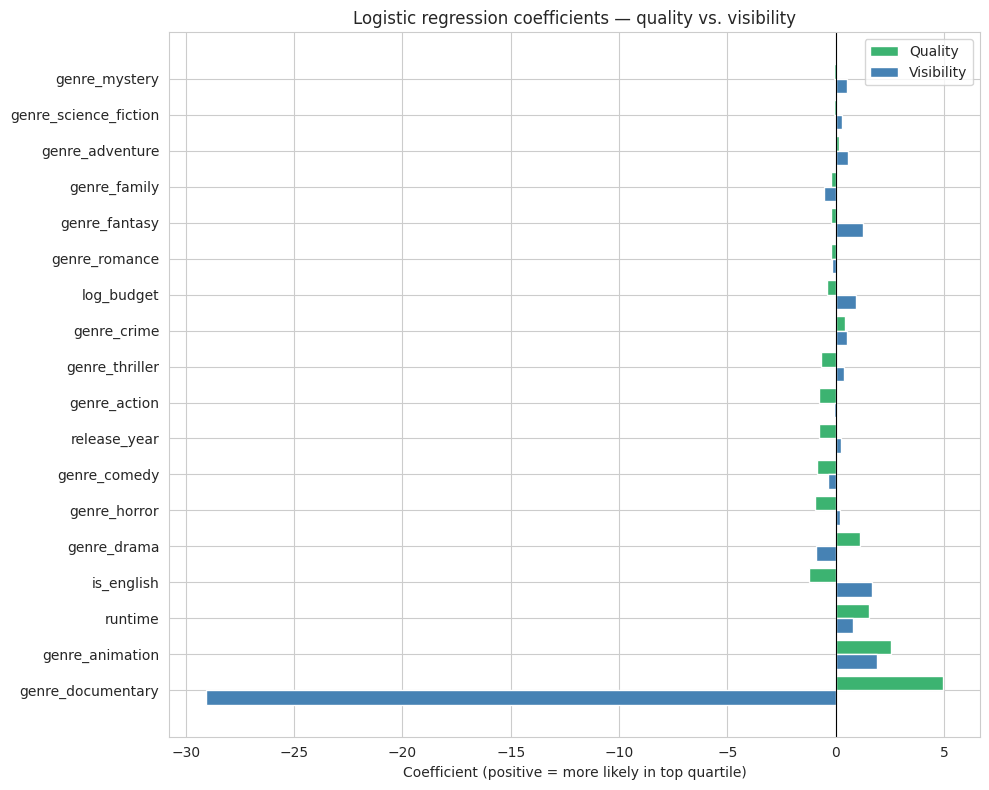

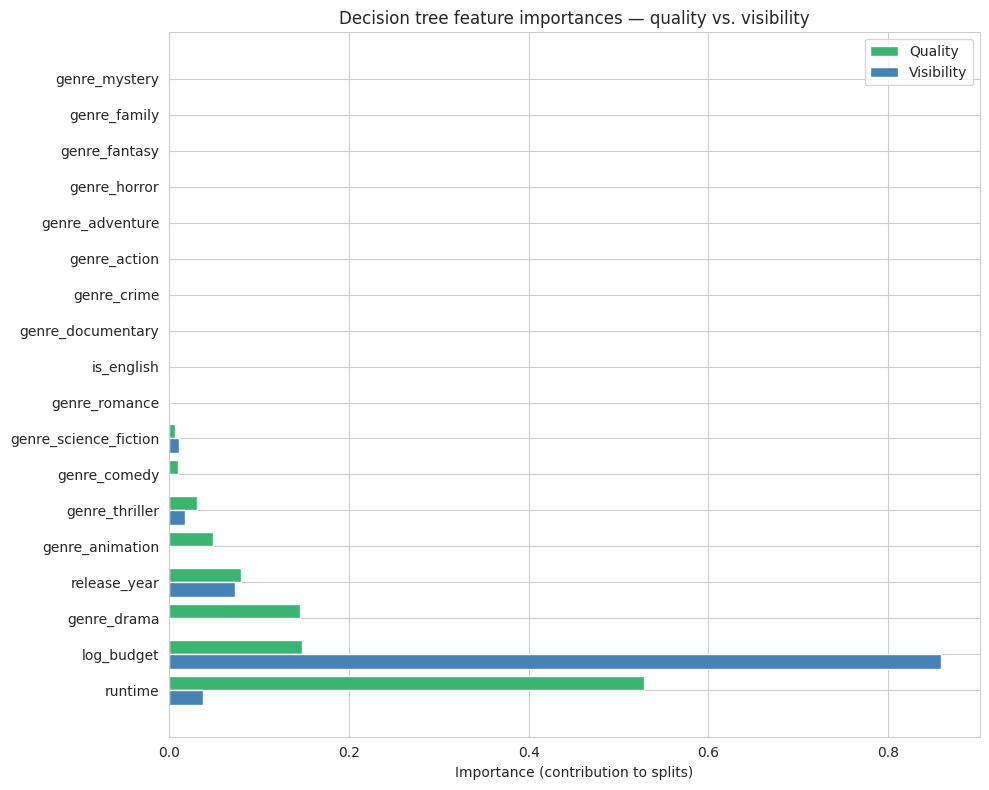

In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- Logistic regression coefficients side by side ---
coef_q = pd.DataFrame({
    "feature":     X_train_sm.columns,        # from the quality section
    "coef_quality": logit_sm_q.params.values,
}).set_index("feature")

coef_v = pd.DataFrame({
    "feature":       X_train_sm.columns,      # same columns, visibility section
    "coef_visibility": logit_sm_v.params.values,
}).set_index("feature")

coef_combined = coef_q.join(coef_v).drop(index="const")
coef_combined = coef_combined.reindex(
    coef_combined["coef_quality"].abs().sort_values(ascending=False).index
)

fig, ax = plt.subplots(figsize=(10, 8))
x = np.arange(len(coef_combined))
width = 0.4
ax.barh(x + width/2, coef_combined["coef_quality"],    width, label="Quality",    color="mediumseagreen")
ax.barh(x - width/2, coef_combined["coef_visibility"], width, label="Visibility", color="steelblue")
ax.set_yticks(x)
ax.set_yticklabels(coef_combined.index)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Logistic regression coefficients — quality vs. visibility")
ax.set_xlabel("Coefficient (positive = more likely in top quartile)")
ax.legend()
plt.tight_layout()
plt.show()

# --- Decision tree importances side by side ---
imp_q = pd.DataFrame({
    "feature":        feature_cols,
    "imp_quality":    tree_q.feature_importances_,
}).set_index("feature")

imp_v = pd.DataFrame({
    "feature":           feature_cols,
    "imp_visibility":    tree_v.feature_importances_,
}).set_index("feature")

imp_combined = imp_q.join(imp_v)
imp_combined = imp_combined.reindex(
    imp_combined["imp_quality"].sort_values(ascending=False).index
)

fig, ax = plt.subplots(figsize=(10, 8))
x = np.arange(len(imp_combined))
ax.barh(x + width/2, imp_combined["imp_quality"],    width, label="Quality",    color="mediumseagreen")
ax.barh(x - width/2, imp_combined["imp_visibility"], width, label="Visibility", color="steelblue")
ax.set_yticks(x)
ax.set_yticklabels(imp_combined.index)
ax.set_title("Decision tree feature importances — quality vs. visibility")
ax.set_xlabel("Importance (contribution to splits)")
ax.legend()
plt.tight_layout()
plt.show()